# Qwen3-14B 스터디 추천 LoRA 학습 (Unsloth)

- **태스크**: 사용자 주제/기술스택/일정 → 스터디 계획 JSON 생성
- **GPU**: SSAFY L40S 46GB
- **D106팀 - GPU Device 3**

⚠️ 14B OOM 나면 → `train_recommend_qwen3_8b.ipynb` 사용

## 1. GPU 설정 + 환경 확인

In [1]:
import os
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "3"

import gc
import torch
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

print(f"CUDA: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0)}")
total_mem = torch.cuda.get_device_properties(0).total_memory / 1024**3
print(f"VRAM: {total_mem:.1f} GB")

CUDA: True
GPU: NVIDIA L40S
VRAM: 44.5 GB


## 2. 데이터 로드 + 토큰 길이 분석

In [2]:
import json
import numpy as np
from transformers import AutoTokenizer

TRAIN_PATH = "./recommend_training_data_train.json"
VAL_PATH = "./recommend_training_data_val.json"

with open(TRAIN_PATH, "r", encoding="utf-8") as f:
    train_raw = json.load(f)
with open(VAL_PATH, "r", encoding="utf-8") as f:
    val_raw = json.load(f)

print(f"Train: {len(train_raw)}개")
print(f"Val: {len(val_raw)}개")
print(f"\n샘플 키: {list(train_raw[0].keys())}")
print(f"샘플 text 앞 300자:\n{train_raw[0]['text'][:300]}")

Train: 1800개
Val: 200개

샘플 키: ['text', 'type', 'topic_input', 'category', 'profile_key', 'difficulty', 'format']
샘플 text 앞 300자:
<|im_start|>system
당신은 IT 스터디 계획을 자동 생성하는 전문가입니다.
사용자가 원하는 스터디 주제와 기술 스택, 가용 일정을 분석하여 완성된 스터디 계획을 JSON으로 생성합니다.

반드시 아래 JSON 형식으로만 응답하세요:
{"name": "스터디 제목", "intro": "한줄 소개 (30자 내외)", "description": "상세 설명 (3~5문장)", "topic": "매칭된 세부주제명", "format": "스터디 형식", "difficulty": "BEGINNER|INTERMEDIATE|ADVAN


In [3]:
# 토큰 길이 분석 (Qwen3 토크나이저 기준)
tokenizer_check = AutoTokenizer.from_pretrained("Qwen/Qwen3-14B", trust_remote_code=True)

lengths = [len(tokenizer_check.encode(d["text"])) for d in train_raw]

print(f"[토큰 길이 분포]")
print(f"  평균: {np.mean(lengths):.0f}")
print(f"  중앙값: {np.median(lengths):.0f}")
print(f"  P95: {np.percentile(lengths, 95):.0f}")
print(f"  P99: {np.percentile(lengths, 99):.0f}")
print(f"  최대: {max(lengths)}")
print(f"  최소: {min(lengths)}")

# MAX_SEQ_LENGTH 추천
p99 = int(np.percentile(lengths, 99))
# 64 단위로 올림
recommended = ((p99 // 64) + 1) * 64
print(f"\n추천 MAX_SEQ_LENGTH: {recommended} (P99={p99} 기준)")
print(f"1024 초과: {sum(1 for l in lengths if l > 1024)}개")
print(f"2048 초과: {sum(1 for l in lengths if l > 2048)}개")

del tokenizer_check
gc.collect()

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

[토큰 길이 분포]
  평균: 1031
  중앙값: 1029
  P95: 1097
  P99: 1123
  최대: 1268
  최소: 919

추천 MAX_SEQ_LENGTH: 1152 (P99=1123 기준)
1024 초과: 976개
2048 초과: 0개


148

## 3. 설정

In [4]:
# ===== 모델 설정 =====
MODEL_NAME = "unsloth/Qwen3-14B"
USE_4BIT = True

# ⚠️ 위 토큰 길이 분석 결과에 따라 조정
# P99 기준 추천값을 사용하거나, 데이터가 길면 2048까지 가능
MAX_SEQ_LENGTH = 1536  # 추천 데이터는 요약보다 길 수 있음

# ===== LoRA 설정 (14B 메모리 절약) =====
LORA_R = 32
LORA_ALPHA = 64
LORA_DROPOUT = 0

# ===== 학습 하이퍼파라미터 =====
BATCH_SIZE = 1          # 14B는 반드시 1
GRAD_ACCUM = 8          # effective batch = 8
LEARNING_RATE = 1e-4
NUM_EPOCHS = 3
WARMUP_RATIO = 0.1

OUTPUT_DIR = "./outputs/qwen3-14b-recommend"

print(f"모델: {MODEL_NAME}")
print(f"MAX_SEQ_LENGTH: {MAX_SEQ_LENGTH}")
print(f"LoRA: r={LORA_R}, alpha={LORA_ALPHA}")
print(f"Batch: {BATCH_SIZE} x {GRAD_ACCUM} = {BATCH_SIZE * GRAD_ACCUM}")
print(f"Epochs: {NUM_EPOCHS}")

모델: unsloth/Qwen3-14B
MAX_SEQ_LENGTH: 1536
LoRA: r=32, alpha=64
Batch: 1 x 8 = 8
Epochs: 3


## 4. 모델 로드 (Unsloth 4-bit)

In [5]:
from unsloth import FastLanguageModel

gc.collect()
torch.cuda.empty_cache()

print(f"모델 로딩: {MODEL_NAME}")

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=None,
    load_in_4bit=USE_4BIT,
)

print(f"모델 로드 완료!")
print(f"VRAM: {torch.cuda.memory_allocated(0) / 1024**3:.2f} GB")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


/tmp/ipykernel_2833323/1390664884.py:1: UserWarning: WARNING: Unsloth should be imported before [transformers] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from unsloth import FastLanguageModel


🦥 Unsloth Zoo will now patch everything to make training faster!
모델 로딩: unsloth/Qwen3-14B
==((====))==  Unsloth 2026.1.4: Fast Qwen3 patching. Transformers: 4.57.6.
   \\   /|    NVIDIA L40S. Num GPUs = 1. Max memory: 44.521 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

모델 로드 완료!
VRAM: 10.37 GB


## 5. LoRA 설정

In [6]:
model = FastLanguageModel.get_peft_model(
    model,
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=42,
)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"학습 파라미터: {trainable:,} ({100 * trainable / total:.2f}%)")
print(f"VRAM: {torch.cuda.memory_allocated(0) / 1024**3:.2f} GB")

Unsloth 2026.1.4 patched 40 layers with 40 QKV layers, 40 O layers and 40 MLP layers.


학습 파라미터: 128,450,560 (1.48%)
VRAM: 10.85 GB


## 6. [BEFORE] 파인튜닝 전 테스트

In [7]:
TEST_INPUT = """스터디 주제: Spring Boot 학습
기술 스택: Java, Spring Boot, JPA, MySQL, Redis, Docker, Git
가용 일정: 화 20:00-22:00, 목 20:00-22:00
선호 기간: 4주

위 정보를 바탕으로 완성된 스터디 계획을 JSON으로 생성해주세요."""

SYSTEM_PROMPT = train_raw[0]["text"].split("<|im_start|>system\n")[1].split("<|im_end|>")[0]

def run_inference(model, tokenizer, user_input, system_prompt=SYSTEM_PROMPT):
    FastLanguageModel.for_inference(model)
    prompt = f"<|im_start|>system\n{system_prompt}<|im_end|>\n<|im_start|>user\n{user_input}<|im_end|>\n<|im_start|>assistant\n"
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=512,
            temperature=0.7,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
        )
    response = tokenizer.decode(outputs[0], skip_special_tokens=False)
    start = response.find("<|im_start|>assistant\n") + len("<|im_start|>assistant\n")
    end = response.find("<|im_end|>", start)
    return response[start:end].strip() if end != -1 else response[start:].strip()

print("=" * 60)
print("[BEFORE] 파인튜닝 전")
print("=" * 60)
before_result = run_inference(model, tokenizer, TEST_INPUT)
print(before_result[:800])

[BEFORE] 파인튜닝 전
<think>
Okay, let's tackle this user's request. They want a study plan for learning Spring Boot with specific tech stack and schedule. First, I need to parse all the given information.

The main topic is Spring Boot, and the tech stack includes Java, Spring Boot, JPA, MySQL, Redis, Docker, Git. The user is available on Tuesdays and Thursdays from 8 PM to 10 PM, and they prefer a 4-week duration. 

I should start by determining the difficulty level. Since they mentioned they have some experience with the tech stack, maybe INTERMEDIATE. But wait, the user didn't explicitly say they have prior experience. Hmm, the rules say if they already have the tech, set to INTERMEDIATE or higher. But the user hasn't specified that. Maybe I should default to BEGINNER unless told otherwise. Wait, the user'


## 7. 데이터셋 준비

In [8]:
from datasets import Dataset

train_dataset = Dataset.from_list(train_raw)
val_dataset = Dataset.from_list(val_raw)

print(f"Train: {len(train_dataset)}개")
print(f"Val: {len(val_dataset)}개")
print(f"\n사용 컬럼: {train_dataset.column_names}")

Train: 1800개
Val: 200개

사용 컬럼: ['text', 'type', 'topic_input', 'category', 'profile_key', 'difficulty', 'format']


## 8. Trainer 설정 + 학습 실행

In [9]:
from trl import SFTTrainer
from transformers import TrainingArguments

FastLanguageModel.for_training(model)

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LEARNING_RATE,
    warmup_ratio=WARMUP_RATIO,
    lr_scheduler_type="cosine",
    weight_decay=0.01,
    optim="adamw_8bit",
    bf16=True,
    fp16=False,
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=50,
    save_strategy="steps",
    save_steps=50,
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none",
    seed=42,
)

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    args=training_args,
    max_seq_length=MAX_SEQ_LENGTH,
    dataset_text_field="text",
    packing=False,
)

print("Trainer 준비 완료")
print(f"VRAM: {torch.cuda.memory_allocated(0) / 1024**3:.2f} GB")

Unsloth: Tokenizing ["text"] (num_proc=100):   0%|          | 0/1800 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=100):   0%|          | 0/200 [00:00<?, ? examples/s]

Trainer 준비 완료
VRAM: 11.22 GB


In [10]:
gc.collect()
torch.cuda.empty_cache()

print("=" * 60)
print("학습 시작!")
print("=" * 60)

train_result = trainer.train()

print(f"\n학습 완료!")
print(f"Steps: {train_result.global_step}")
print(f"Train Loss: {train_result.training_loss:.4f}")

The model is already on multiple devices. Skipping the move to device specified in `args`.


학습 시작!


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,800 | Num Epochs = 3 | Total steps = 675
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 128,450,560 of 14,896,757,760 (0.86% trained)


Step,Training Loss,Validation Loss
50,0.240800,0.219678
100,0.180900,0.174792
150,0.160900,0.162078
200,0.156800,0.155455
250,0.143400,0.152644
300,0.141600,0.149480
350,0.146400,0.147770
400,0.143000,0.146382
450,0.137500,0.144882
500,0.124100,0.144684


Unsloth: Not an error, but Qwen3ForCausalLM does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient



학습 완료!
Steps: 675
Train Loss: 0.1927


## 9. 학습 곡선

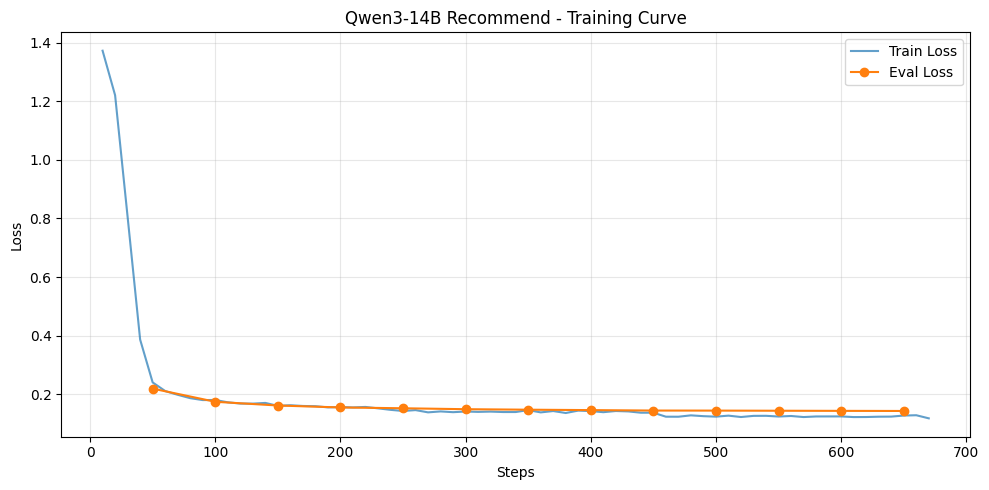

In [11]:
import matplotlib.pyplot as plt

logs = trainer.state.log_history
train_loss = [(x["step"], x["loss"]) for x in logs if "loss" in x]
eval_loss = [(x["step"], x["eval_loss"]) for x in logs if "eval_loss" in x]

plt.figure(figsize=(10, 5))
if train_loss:
    steps, losses = zip(*train_loss)
    plt.plot(steps, losses, label="Train Loss", alpha=0.7)
if eval_loss:
    steps, losses = zip(*eval_loss)
    plt.plot(steps, losses, label="Eval Loss", marker="o")

plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Qwen3-14B Recommend - Training Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("recommend_14b_training_curve.png", dpi=150)
plt.show()

## 10. [AFTER] 파인튜닝 후 테스트

In [12]:
print("=" * 60)
print("[AFTER] 파인튜닝 후")
print("=" * 60)
after_result = run_inference(model, tokenizer, TEST_INPUT)
print(after_result[:800])

# JSON 파싱 확인
try:
    clean = after_result
    if "```json" in clean:
        clean = clean.split("```json")[1].split("```")[0].strip()
    elif "```" in clean:
        clean = clean.split("```")[1].split("```")[0].strip()
    parsed = json.loads(clean)
    print(f"\nJSON 파싱 성공!")
    print(f"필드: {list(parsed.keys())}")
except Exception as e:
    print(f"\nJSON 파싱 실패: {e}")

[AFTER] 파인튜닝 후
{"name": "Spring Boot와 JPA로 웹앱 만들기", "intro": "Spring Boot로 웹 애플리케이션 개발하기", "description": "이번 스터디에서는 Spring Boot와 JPA를 사용하여 실제 웹 애플리케이션을 개발하는 방법을 배웁니다. MySQL과 Redis를 데이터베이스로 활용하고, Docker를 통해 배포 환경을 설정합니다. Git을 이용한 버전 관리도 함께 진행하여 실무에서 필요한 기술들을 익힐 수 있습니다.", "topic": "Spring Boot", "format": "프로젝트", "difficulty": "INTERMEDIATE", "goal": "Spring Boot를 활용한 웹 애플리케이션 개발 능력 향상", "textbook": "Spring in Action, JPA의 정석", "prerequisites": "Java 기초 지식", "processDetail": "1주차: Spring Boot 기본 구조 이해 및 프로젝트 세팅\n2주차: JPA를 활용한 데이터베이스 연동\n3주차: Redis 캐싱 및 Docker를 통한 배포\n4주차: 최종 프로젝트 발표 및 코드 리뷰", "durationWeeks": 4, "scheduleSuggestion": {"days": ["화", "목"], "time": "20:00-22:00"}}

JSON 파싱 성공!
필드: ['name', 'intro', 'description', 'topic', 'format', 'difficulty', 'goal', 'textbook', 'prerequisites', 'processDetail', 'durationWeeks', 'scheduleSuggestion']


In [13]:
# Before vs After 비교
print("=" * 60)
print("[BEFORE]")
print("-" * 40)
print(before_result[:500])
print()
print("[AFTER]")
print("-" * 40)
print(after_result[:500])
print("=" * 60)

[BEFORE]
----------------------------------------
<think>
Okay, let's tackle this user's request. They want a study plan for learning Spring Boot with specific tech stack and schedule. First, I need to parse all the given information.

The main topic is Spring Boot, and the tech stack includes Java, Spring Boot, JPA, MySQL, Redis, Docker, Git. The user is available on Tuesdays and Thursdays from 8 PM to 10 PM, and they prefer a 4-week duration. 

I should start by determining the difficulty level. Since they mentioned they have some experience 

[AFTER]
----------------------------------------
{"name": "Spring Boot와 JPA로 웹앱 만들기", "intro": "Spring Boot로 웹 애플리케이션 개발하기", "description": "이번 스터디에서는 Spring Boot와 JPA를 사용하여 실제 웹 애플리케이션을 개발하는 방법을 배웁니다. MySQL과 Redis를 데이터베이스로 활용하고, Docker를 통해 배포 환경을 설정합니다. Git을 이용한 버전 관리도 함께 진행하여 실무에서 필요한 기술들을 익힐 수 있습니다.", "topic": "Spring Boot", "format": "프로젝트", "difficulty": "INTERMEDIATE", "goal": "Spring Boot를 활용한 웹 애플리케이션 개발 능력 향상", "textbook": "Spring in A

## 11. Test 정량 평가 (JSON 유효율)

In [14]:
required_keys = ["name", "intro", "description", "topic", "format",
                 "difficulty", "goal", "textbook", "processDetail",
                 "durationWeeks", "scheduleSuggestion"]

eval_count = min(30, len(val_raw))
json_valid = 0
key_complete = 0

for i in range(eval_count):
    text = val_raw[i]["text"]
    # user 메시지 추출
    user_start = text.find("<|im_start|>user\n") + len("<|im_start|>user\n")
    user_end = text.find("<|im_end|>", user_start)
    user_msg = text[user_start:user_end]

    result = run_inference(model, tokenizer, user_msg)

    try:
        clean = result
        if "```json" in clean:
            clean = clean.split("```json")[1].split("```")[0].strip()
        elif "```" in clean:
            clean = clean.split("```")[1].split("```")[0].strip()
        parsed = json.loads(clean)
        json_valid += 1
        missing = [k for k in required_keys if k not in parsed]
        if not missing:
            key_complete += 1
    except:
        pass

    if (i + 1) % 10 == 0:
        print(f"  진행: {i+1}/{eval_count} (JSON: {json_valid}, 키 완전: {key_complete})")

print(f"\n[결과]")
print(f"  JSON 유효율: {json_valid}/{eval_count} ({json_valid/eval_count:.1%})")
print(f"  키 완전율: {key_complete}/{eval_count} ({key_complete/eval_count:.1%})")

  진행: 10/30 (JSON: 10, 키 완전: 10)
  진행: 20/30 (JSON: 20, 키 완전: 20)
  진행: 30/30 (JSON: 30, 키 완전: 30)

[결과]
  JSON 유효율: 30/30 (100.0%)
  키 완전율: 30/30 (100.0%)


## 12. 모델 저장 + GGUF 변환

In [15]:
LORA_SAVE = f"{OUTPUT_DIR}/lora"
model.save_pretrained(LORA_SAVE)
tokenizer.save_pretrained(LORA_SAVE)
print(f"LoRA 저장: {LORA_SAVE}")

LoRA 저장: ./outputs/qwen3-14b-recommend/lora


In [ ]:
# GGUF 변환
GGUF_DIR = "./models/qwen3-14b-recommend"
print("GGUF Q4_K_M 변환 중...")
model.save_pretrained_gguf(GGUF_DIR, tokenizer, quantization_method="q4_k_m")
print(f"GGUF 저장: {GGUF_DIR}")

for f in os.listdir(GGUF_DIR):
    if f.endswith(".gguf"):
        size = os.path.getsize(os.path.join(GGUF_DIR, f)) / 1024**3
        print(f"  {f}: {size:.1f} GB")

GGUF Q4_K_M 변환 중...
Unsloth: Merging model weights to 16-bit format...


config.json:   0%|          | 0.00/754 [00:00<?, ?B/s]

Found HuggingFace hub cache directory: /home/j-i14d106/.cache/huggingface/hub


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

...

model-00006-of-00006.safetensors:   0%|          | 0.00/4.73G [00:00<?, ?B/s]

Unsloth: Preparing safetensor model files: 100%|██████████| 6/6 [03:54<00:00, 39.03s/it]


Note: tokenizer.model not found (this is OK for non-SentencePiece models)


Unsloth: Merging weights into 16bit: 100%|██████████| 6/6 [00:52<00:00,  8.71s/it]


Unsloth: Merge process complete. Saved to `/home/j-i14d106/models/qwen3-14b-recommend`
Unsloth: Converting to GGUF format...
==((====))==  Unsloth: Conversion from HF to GGUF information
   \\   /|    [0] Installing llama.cpp might take 3 minutes.
O^O/ \_/ \    [1] Converting HF to GGUF bf16 might take 3 minutes.
\        /    [2] Converting GGUF bf16 to ['q4_k_m'] might take 10 minutes each.
 "-____-"     In total, you will have to wait at least 16 minutes.

Unsloth: Installing llama.cpp. This might take 3 minutes...
Unsloth: llama.cpp folder exists but binaries not found - will rebuild
Unsloth: Updating system package directories
Unsloth: Missing packages: cmake
Unsloth: Will attempt to install missing system packages.
Unsloth: Installing packages: cmake
